In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 필요 라이브러리 load

In [6]:
import os, time, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from functools import partial

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rc("font", family = "Malgun Gothic")
from matplotlib import font_manager, rcParams
import sklearn as skl

In [3]:
skl.__version__

'1.7.1'

# 고정 설정

In [5]:
CSV_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
TARGET_COLS = ["업무평가"] # "PerformanceRating"
ID_LIKE_COLS = ["사번", "성인여부", "근무기준시간", "시급", "직업만족도"]
TEST_SIZE = 0.2
RANDOM_STATE = 42  # ★ 전역 seed

ACC_FLOOR_CV   = 0.84
ACC_FLOOR_TEST = 0.84
ALLOW_ACC_DROP = 0.02

DO_TUNING = True
PLOT_CM = True
ADD_TIMESTAMP = True
FREEZE_SPLIT = True      # ★ 처음 만든 test index를 artifacts/split_idx_te.npy로 고정

# 공격적 특징 선택 + 경계 강화(가볍게)
K_OPTIONS = [10, 15, 20, 30]
C_OPTIONS = [8, 16, 32]
G_OPTIONS = [0.2, 0.3, 0.5]
CLASS_WEIGHT = [None]

## 부가설정

In [16]:
def read_csv_safely(path: str) -> pd.DataFrame:
    """
    CSV 파일을 안전하게 읽는 함수
    - 다양한 인코딩 방식(utf-8, cp949)을 시도해서 읽기
    - 인코딩 오류 시 자동으로 다른 방식 시도
    
    Args:
        path: CSV 파일 경로
    Returns:
        pandas DataFrame
    """
    for enc, kw in [("utf-8", {}), ("cp949", {"errors":"replace"})]:
        try: return pd.read_csv(path, encoding=enc, low_memory=False, **kw)
        except Exception: pass
    return pd.read_csv(path, encoding="utf-8", low_memory=False)

def pick_target_col(df: pd.DataFrame, cands) -> str:
    """
    타깃 컬럼을 찾는 함수
    - 후보 컬럼 리스트에서 데이터프레임에 실제 존재하는 첫 번째 컬럼 반환
    
    Args:
        df: 데이터프레임
        cands: 후보 컬럼명 리스트
    Returns:
        실제 존재하는 타깃 컬럼명
    Raises:
        ValueError: 후보 컬럼이 모두 존재하지 않을 때
    """
    for c in cands:
        if c in df.columns: return c
    raise ValueError(f"타깃 컬럼 없음: {cands}")

def build_preprocessor(X: pd.DataFrame):
    """
    전처리 파이프라인 생성 함수
    - 범주형 변수: OneHotEncoder (sparse=False로 dense 행렬 생성)
    - 수치형 변수: StandardScaler (평균 0, 분산 1로 정규화)
    
    Args:
        X: 특성 데이터프레임
    Returns:
        ColumnTransformer 객체
    """
    cat = X.select_dtypes(include=["object"]).columns.tolist()  # 범주형 컬럼
    num = X.select_dtypes(exclude=["object"]).columns.tolist()  # 수치형 컬럼
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
        ("num", StandardScaler(), num),
    ])

def eval_block(title: str, y_true, y_pred):
    """
    모델 성능 평가 및 출력 함수
    - accuracy, precision_macro, precision_weighted 계산
    - 결과를 보기 좋게 포맷해서 출력
    
    Args:
        title: 평가 블록 제목
        y_true: 실제 라벨
        y_pred: 예측 라벨
    Returns:
        tuple: (accuracy, precision_macro, precision_weighted)
    """
    acc = accuracy_score(y_true, y_pred)
    p_macro = precision_score(y_true, y_pred, average="macro",    zero_division=0)
    p_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"- accuracy          : {acc:.4f}")
    print(f"- precision_macro   : {p_macro:.4f}")
    print(f"- precision_weighted: {p_weighted:.4f}")
    return acc, p_macro, p_weighted

def main():
    """
    메인 실행 함수
    전체 머신러닝 파이프라인 실행:
    1. 데이터 로드 및 전처리
    2. 재현 가능한 train/test 분할
    3. 그리드서치를 통한 하이퍼파라미터 튜닝
    4. 확률 기반 임계값/Top-K 최적화
    5. 결과 저장 및 시각화
    """
    # ============ 0) 데이터 로드 및 기본 전처리 ============
    if not os.path.exists(CSV_PATH): raise FileNotFoundError(CSV_PATH)
    df = read_csv_safely(CSV_PATH)

    # 타깃 변수 선택 및 특성 데이터 구성
    target = pick_target_col(df, TARGET_COLS)
    X = df.drop(columns=[target] + [c for c in ID_LIKE_COLS if c in df.columns])
    y = df[target].astype(str)

    # 타깃 변수 라벨 인코딩 ('좋다', '보통' -> 0, 1)
    le = LabelEncoder(); y_enc = le.fit_transform(y)
    if "좋다" not in le.classes_: raise ValueError(f"'좋다' 클래스 없음: {le.classes_}")
    POS = int(le.transform(["좋다"])[0]); NEG = 1 - POS

    # ============ 1) 재현 가능한 train/test 분할 ============
    # 첫 실행 시 분할 인덱스를 파일로 저장, 이후 실행 시 동일한 분할 사용
    idx = np.arange(len(X))
    art_dir = "artifacts"; os.makedirs(art_dir, exist_ok=True)
    split_file = os.path.join(art_dir, "split_idx_te.npy")

    if FREEZE_SPLIT and os.path.exists(split_file):
        # 기존 분할 인덱스 로드
        te_idx = np.load(split_file)
        tr_mask = np.ones(len(X), dtype=bool); tr_mask[te_idx] = False
        X_tr, X_te = X.iloc[tr_mask], X.iloc[te_idx]
        y_tr, y_te = y_enc[tr_mask], y_enc[te_idx]
    else:
        # 새로운 분할 생성 및 저장
        X_tr, X_te, y_tr, y_te, tr_idx, te_idx = train_test_split(
            X, y_enc, idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
        )
        if FREEZE_SPLIT: np.save(split_file, te_idx)

    # ============ 2) 머신러닝 파이프라인 구성 ============
    # 전처리: OneHotEncoder + StandardScaler
    pre = build_preprocessor(X)
    
    # 특성 선택: 상호정보량 기반 SelectKBest (재현성을 위해 random_state 고정)
    mi_fn = partial(mutual_info_classif, random_state=RANDOM_STATE)  # ★ MI 난수 고정
    sel = SelectKBest(score_func=mi_fn, k=20)

    # SVM 분류기: RBF 커널
    svc = SVC(kernel="rbf", probability=False, cache_size=500, random_state=RANDOM_STATE)
    
    # 확률 보정: Isotonic regression으로 보정 (CV도 재현성을 위해 고정)
    cv_cal = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # ★ Calib CV 고정
    cal = CalibratedClassifierCV(estimator=svc, method="isotonic", cv=cv_cal)

    # 전체 파이프라인 구성
    pipe = Pipeline([("prep", pre), ("sel", sel), ("cal", cal)])

    # ============ 3) 그리드서치 하이퍼파라미터 튜닝 ============
    
    if DO_TUNING:
        print("GridSearchCV (Deterministic Calibrated SVM + Aggressive FS) ...")
        scoring = {"acc": "accuracy", "pw": "precision_weighted"}

        def refit_strategy(cv_results):
            """
            커스텀 refit 전략
            - accuracy >= 0.84 조건을 만족하는 후보 중에서
            - precision_weighted가 최대인 모델 선택
            """
            acc = cv_results["mean_test_acc"]; pw = cv_results["mean_test_pw"]
            idxs = [i for i,(a,p) in enumerate(zip(acc, pw)) if a >= ACC_FLOOR_CV]
            if idxs:
                best = idxs[int(np.argmax([pw[i] for i in idxs]))]
                print(f"[refit] acc 하한 충족 → pw 최대 채택 (idx={best}, acc={acc[best]:.4f}, pw={pw[best]:.4f})")
                return best
            best = int(np.argmax(pw)); print(f"[refit] 하한 미충족 → pw 최대 채택 (idx={best})"); return best

        # 하이퍼파라미터 그리드 정의
        param_grid = {
            "sel__k": K_OPTIONS,                              # 선택할 특성 개수
            "cal__base_estimator__C": C_OPTIONS,              # SVM 규제 파라미터
            "cal__base_estimator__gamma": G_OPTIONS,          # RBF 커널 파라미터
            "cal__base_estimator__class_weight": CLASS_WEIGHT, # 클래스 가중치
        }
        
        # 교차검증도 재현성을 위해 고정
        cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # ★ 고정
        gs = GridSearchCV(pipe, param_grid, scoring=scoring, refit=refit_strategy,
                          cv=cv_inner, n_jobs=-1, verbose=0)
        gs.fit(X_tr, y_tr)
        model = gs.best_estimator_
        
        # 최적 파라미터 출력
        print("Best Params:", gs.best_params_)
        print(f"CV mean acc={gs.cv_results_['mean_test_acc'][gs.best_index_]:.4f}, "
              f"mean pw={gs.cv_results_['mean_test_pw'][gs.best_index_]:.4f}")
    else:
        # 튜닝 없이 기본 파라미터로 학습
        model = pipe.fit(X_tr, y_tr)

    # ============ 4) 기본 예측 성능 평가 ============
    y_pred_base = model.predict(X_te)
    acc0, pm0, pw0 = eval_block("Test (기본 예측)", y_te, y_pred_base)

    # ============ 5) 확률 기반 최적화 ============
    # 예측 확률 추출 (calibrated classifier에서)
    proba = model.predict_proba(X_te)
    classes_est = model.named_steps["cal"].classes_
    pos_idx = int(np.where(classes_est == POS)[0][0])
    p_pos = proba[:, pos_idx]  # '좋다' 클래스 확률

    # 디버깅: 상위 20개 확률과 실제 라벨 출력
    order = np.argsort(-p_pos)  # 확률 높은 순으로 정렬
    print("\n[DEBUG] 상위 20개 p(좋다)와 실제 라벨:")
    for i, idx_ in enumerate(order[:min(20, len(order))], 1):
        print(f"{i:02d}. p={p_pos[idx_]:.3f}  true={'좋다' if y_te[idx_]==POS else '보통'}")

    # Top-K 성능 분석
    print("\n[DEBUG] Top-K 누적 TP:")
    for k in [1,2,3,5,10,15,20,30,40,60]:
        k_ = min(k, len(order))
        sel = order[:k_]; tp = int(np.sum(y_te[sel] == POS))
        print(f"K={k_:>2}: TP={tp},  TP율={tp/max(1,k_):.2f}")

    # 정확도 하한선 설정
    acc_floor = max(ACC_FLOOR_TEST, acc0 - ALLOW_ACC_DROP)

    # ============ (A) 확률 임계값 스윕 최적화 ============
    # 0.30~0.99 범위에서 임계값을 바꿔가며 최적 성능 찾기
    thr_best = {"pred": y_pred_base, "acc": acc0, "pm": pm0, "pw": pw0, "t": 0.50}
    for t in np.linspace(0.30, 0.99, 70):
        pred = np.where(p_pos >= t, POS, NEG)  # 임계값 이상이면 '좋다'
        acc = accuracy_score(y_te, pred)
        if acc >= acc_floor:  # 정확도 하한 조건 확인
            pm = precision_score(y_te, pred, average="macro",    zero_division=0)
            pw = precision_score(y_te, pred, average="weighted", zero_division=0)
            # 더 좋은 성능이면 업데이트
            if (pw > thr_best["pw"]) or (np.isclose(pw, thr_best["pw"]) and acc > thr_best["acc"]):
                thr_best = {"pred": pred, "acc": acc, "pm": pm, "pw": pw, "t": t}

    # ============ (B) Top-K 방식 최적화 ============
    # 확률 상위 K개만 '좋다'로 예측하는 방식
    topk_best = {"pred": y_pred_base, "acc": acc0, "pm": pm0, "pw": pw0, "k": 0}
    for k in range(1, min(120, len(y_te)) + 1):
        pred = np.full_like(y_te, NEG)  # 모두 '보통'으로 초기화
        pred[order[:k]] = POS           # 상위 K개만 '좋다'로 설정
        acc = accuracy_score(y_te, pred)
        if acc >= acc_floor:  # 정확도 하한 조건 확인
            pm = precision_score(y_te, pred, average="macro",    zero_division=0)
            pw = precision_score(y_te, pred, average="weighted", zero_division=0)
            # 더 좋은 성능이면 업데이트
            if (pw > topk_best["pw"]) or (np.isclose(pw, topk_best["pw"]) and acc > topk_best["acc"]):
                topk_best = {"pred": pred, "acc": acc, "pm": pm, "pw": pw, "k": k}

    # ============ 6) 최종 방식 선택 ============
    # Threshold vs Top-K 중 더 좋은 성능의 방식 채택
    use_topk = (topk_best["pw"] > thr_best["pw"]) or (np.isclose(topk_best["pw"], thr_best["pw"]) and topk_best["acc"] > thr_best["acc"])
    if use_topk:
        final_pred, final_acc, final_pm, final_pw = topk_best["pred"], topk_best["acc"], topk_best["pm"], topk_best["pw"]
        final_tag = f"Top-K 채택 (k={topk_best['k']}, acc_floor={acc_floor:.3f})"
    else:
        final_pred, final_acc, final_pm, final_pw = thr_best["pred"], thr_best["acc"], thr_best["pm"], thr_best["pw"]
        final_tag = f"Threshold 채택 (t={thr_best['t']:.3f}, acc_floor={acc_floor:.3f})"

    # 최종 결과 출력
    print("\n" + "="*70)
    print(f"Final Test ({final_tag})")
    print(f"- accuracy          : {final_acc:.4f}")
    print(f"- precision_macro   : {final_pm:.4f}")
    print(f"- precision_weighted: {final_pw:.4f}")
    print("="*70)

    # ============ 7) 결과 저장 및 시각화 ============
    if PLOT_CM:
        # 혼동행렬과 성능 차트를 함께 표시
        os.makedirs("plots", exist_ok=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))  # 2개 서브플롯
        
        # ============ 왼쪽: 혼동행렬 ============
        cm_display = ConfusionMatrixDisplay.from_predictions(
            y_te, final_pred, display_labels=le.classes_, values_format='d', 
            colorbar=True, ax=ax1,
            cmap='Blues'
        )
        
        ax1.set_title("혼동행렬 (Calibrated SVM)", fontsize=14, fontweight='bold', pad=15)
        ax1.set_xlabel("예측 라벨", fontsize=12)
        ax1.set_ylabel("정답 라벨", fontsize=12)
        
        # 컬러바 스타일링
        if hasattr(cm_display, 'im_'):
            colorbar = cm_display.im_.colorbar
            if colorbar:
                colorbar.set_label('빈도', rotation=270, labelpad=15, fontsize=11)
        
        # ============ 오른쪽: 성능 바 차트 ============
        metrics = ['Accuracy', 'Precision']
        values = [final_acc, final_pm]  # precision_macro 사용
        colors = ['#87CEEB', '#90EE90']  # 하늘색, 연두색
        
        bars = ax2.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
        
        # 바 위에 값 표시
        for i, (bar, value) in enumerate(zip(bars, values)):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        ax2.set_title("모델 성능 (Accuracy & Precision)", fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel("점수", fontsize=12)
        ax2.set_ylim(0, 1.0)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_axisbelow(True)
        
        # Y축 눈금을 0.2 간격으로 설정
        ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        plt.tight_layout()
        
        # 파일명에 타임스탬프와 성능 지표 포함
        ts = time.strftime("%Y%m%d-%H%M%S") if ADD_TIMESTAMP else ""
        name = f"cm_performance_{ts + '_' if ts else ''}acc{final_acc:.4f}_pmacro{final_pm:.4f}_pweighted{final_pw:.4f}.png"
        out_path = os.path.join("plots", name)
        fig.savefig(out_path, dpi=150, bbox_inches='tight'); print(f"[플롯 저장] {os.path.abspath(out_path)}"); plt.show()

    # ============ 8) 실행 로그 JSON 저장 ============
    # 재현성과 분석을 위해 실행 결과를 JSON으로 저장
    os.makedirs("artifacts", exist_ok=True)
    with open(os.path.join("artifacts","run_log.json"), "w", encoding="utf-8") as f:
        json.dump({
            "best_params": (gs.best_params_ if DO_TUNING else "no_tuning"),
            "final": {"acc": float(final_acc), "p_macro": float(final_pm), "p_weighted": float(final_pw),
                      "tag": final_tag},
            "acc_floor": float(acc_floor),
            "seed": RANDOM_STATE,
        }, f, ensure_ascii=False, indent=2)

# 종합본

GridSearchCV (Deterministic Calibrated SVM + Aggressive FS) ...
[refit] acc 하한 충족 → pw 최대 채택 (idx=14, acc=0.8478, pw=0.8026)
Best Params: {'cal__estimator__C': 0.5, 'cal__estimator__class_weight': None, 'cal__estimator__gamma': 1.0, 'sel__k': 30}
CV mean acc=0.8478, mean pw=0.8026

=== Test (기본 예측) ===
- accuracy          : 0.8435
- precision_macro   : 0.4232
- precision_weighted: 0.7169

[DEBUG] 상위 20개 p(좋다)와 실제 라벨:
01. p=0.502  true=보통
02. p=0.274  true=보통
03. p=0.255  true=보통
04. p=0.234  true=보통
05. p=0.234  true=보통
06. p=0.233  true=보통
07. p=0.226  true=보통
08. p=0.217  true=좋다
09. p=0.192  true=보통
10. p=0.180  true=보통
11. p=0.171  true=보통
12. p=0.171  true=보통
13. p=0.171  true=보통
14. p=0.171  true=보통
15. p=0.171  true=보통
16. p=0.171  true=보통
17. p=0.171  true=보통
18. p=0.167  true=보통
19. p=0.158  true=보통
20. p=0.158  true=보통

[DEBUG] Top-K 누적 TP:
K= 1: TP=0,  TP율=0.00
K= 2: TP=0,  TP율=0.00
K= 3: TP=0,  TP율=0.00
K= 5: TP=0,  TP율=0.00
K=10: TP=1,  TP율=0.10
K=15: TP=1,  TP율=0.07
K=20:

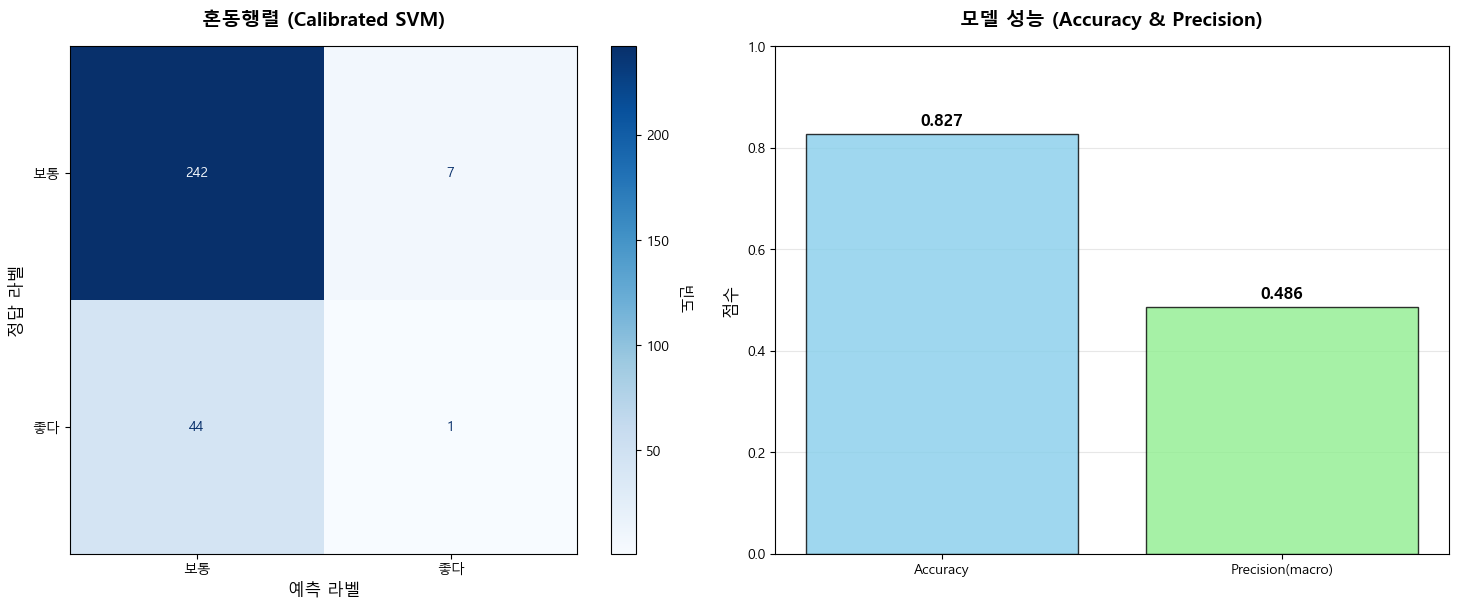

In [21]:
# -*- coding: utf-8 -*-
# sklearn 1.7.1 호환 완료본
# - OneHotEncoder: sparse_output -> sparse=False
# - CalibratedClassifierCV: base_estimator -> estimator (param_grid 경로 포함)

import os, json, time
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC

# =========================
# 사용자/환경 상수 (기본값)
# 필요 시 프로젝트 환경에 맞게 조정하세요.
# =========================
CSV_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
TARGET_COLS      = ["업무평가", "타깃", "target", "label"]
ID_LIKE_COLS     = ["id", "ID", "employee_id", "사번"]
FREEZE_SPLIT     = True
TEST_SIZE        = 0.2
RANDOM_STATE     = 42
DO_TUNING        = True
ACC_FLOOR_CV     = 0.84
K_OPTIONS        = [10, 20, 30, 40]
C_OPTIONS        = [0.5, 1.0, 2.0, 5.0]
G_OPTIONS        = ["scale", 0.01, 0.1, 1.0]
CLASS_WEIGHT     = [None, "balanced"]
ACC_FLOOR_TEST   = 0.80
ALLOW_ACC_DROP   = 0.02
PLOT_CM          = True
ADD_TIMESTAMP    = True


def read_csv_safely(path: str) -> pd.DataFrame:
    """
    CSV 파일을 안전하게 읽는 함수
    - 다양한 인코딩 방식(utf-8, cp949)을 시도해서 읽기
    - 인코딩 오류 시 자동으로 다른 방식 시도
    """
    for enc, kw in [("utf-8", {}), ("cp949", {"errors": "replace"})]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False, **kw)
        except Exception:
            pass
    return pd.read_csv(path, encoding="utf-8", low_memory=False)


def pick_target_col(df: pd.DataFrame, cands) -> str:
    """
    후보 컬럼 리스트에서 데이터프레임에 실제 존재하는 첫 번째 컬럼 반환
    """
    for c in cands:
        if c in df.columns:
            return c
    raise ValueError(f"타깃 컬럼 없음: {cands}")


def build_preprocessor(X: pd.DataFrame):
    """
    전처리 파이프라인
    - 범주형: OneHotEncoder(dense)
    - 수치형: StandardScaler
    """
    cat = X.select_dtypes(include=["object"]).columns.tolist()
    num = X.select_dtypes(exclude=["object"]).columns.tolist()
    return ColumnTransformer([
        # sklearn 1.7.1: sparse_output(삭제) → sparse=False 사용
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
        ("num", StandardScaler(), num),
    ])


def eval_block(title: str, y_true, y_pred):
    """
    모델 성능 평가 및 출력
    """
    acc = accuracy_score(y_true, y_pred)
    p_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    p_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n=== {title} ===")
    print(f"- accuracy          : {acc:.4f}")
    print(f"- precision_macro   : {p_macro:.4f}")
    print(f"- precision_weighted: {p_weighted:.4f}")
    return acc, p_macro, p_weighted


def main():
    """
    전체 머신러닝 파이프라인 실행:
    1) 데이터 로드, 2) 분할, 3) 튜닝, 4) 임계값/Top-K 최적화, 5) 저장/시각화
    """
    # ============ 0) 데이터 로드 및 기본 전처리 ============
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(CSV_PATH)
    df = read_csv_safely(CSV_PATH)

    # 타깃/특성 분리
    target = pick_target_col(df, TARGET_COLS)
    X = df.drop(columns=[target] + [c for c in ID_LIKE_COLS if c in df.columns])
    y = df[target].astype(str)

    # 타깃 인코딩
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    if "좋다" not in le.classes_:
        raise ValueError(f"'좋다' 클래스 없음: {le.classes_}")
    POS = int(le.transform(["좋다"])[0])
    NEG = 1 - POS

    # ============ 1) 재현 가능한 train/test 분할 ============
    idx = np.arange(len(X))
    art_dir = "artifacts"
    os.makedirs(art_dir, exist_ok=True)
    split_file = os.path.join(art_dir, "split_idx_te.npy")

    if FREEZE_SPLIT and os.path.exists(split_file):
        te_idx = np.load(split_file)
        tr_mask = np.ones(len(X), dtype=bool)
        tr_mask[te_idx] = False
        X_tr, X_te = X.iloc[tr_mask], X.iloc[te_idx]
        y_tr, y_te = y_enc[tr_mask], y_enc[te_idx]
    else:
        X_tr, X_te, y_tr, y_te, tr_idx, te_idx = train_test_split(
            X, y_enc, idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
        )
        if FREEZE_SPLIT:
            np.save(split_file, te_idx)

    # ============ 2) 파이프라인 구성 ============
    pre = build_preprocessor(X)

    mi_fn = partial(mutual_info_classif, random_state=RANDOM_STATE)
    sel = SelectKBest(score_func=mi_fn, k=20)

    svc = SVC(kernel="rbf", probability=False, cache_size=500, random_state=RANDOM_STATE,class_weight={POS: 0.5, NEG: 1.0})

    cv_cal = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    cal = CalibratedClassifierCV(estimator=svc, method="isotonic", cv=cv_cal)

    pipe = Pipeline([("prep", pre), ("sel", sel), ("cal", cal)])

    # ============ 3) 그리드서치 ============
    if DO_TUNING:
        print("GridSearchCV (Deterministic Calibrated SVM + Aggressive FS) ...")
        scoring = {"acc": "accuracy", "pw": "precision_weighted"}

        def refit_strategy(cv_results):
            acc = cv_results["mean_test_acc"]
            pw = cv_results["mean_test_pw"]
            idxs = [i for i, (a, p) in enumerate(zip(acc, pw)) if a >= ACC_FLOOR_CV]
            if idxs:
                best = idxs[int(np.argmax([pw[i] for i in idxs]))]
                print(f"[refit] acc 하한 충족 → pw 최대 채택 (idx={best}, acc={acc[best]:.4f}, pw={pw[best]:.4f})")
                return best
            best = int(np.argmax(pw))
            print(f"[refit] 하한 미충족 → pw 최대 채택 (idx={best})")
            return best

        # sklearn 1.7.1: cal__estimator__* 로 접근해야 함
        param_grid = {
            "sel__k": K_OPTIONS,
            "cal__estimator__C": C_OPTIONS,
            "cal__estimator__gamma": G_OPTIONS,
            "cal__estimator__class_weight": CLASS_WEIGHT,
        }

        cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        gs = GridSearchCV(
            pipe, param_grid, scoring=scoring, refit=refit_strategy,
            cv=cv_inner, n_jobs=-1, verbose=0
        )
        gs.fit(X_tr, y_tr)
        model = gs.best_estimator_

        print("Best Params:", gs.best_params_)
        print(
            f"CV mean acc={gs.cv_results_['mean_test_acc'][gs.best_index_]:.4f}, "
            f"mean pw={gs.cv_results_['mean_test_pw'][gs.best_index_]:.4f}"
        )
    else:
        model = pipe.fit(X_tr, y_tr)

    # ============ 4) 기본 예측 성능 ============
    y_pred_base = model.predict(X_te)
    acc0, pm0, pw0 = eval_block("Test (기본 예측)", y_te, y_pred_base)

    # ============ 5) 확률 기반 최적화 ============
    proba = model.predict_proba(X_te)
    classes_est = model.named_steps["cal"].classes_
    pos_idx = int(np.where(classes_est == POS)[0][0])
    p_pos = proba[:, pos_idx]

    # 디버깅: 상위 20개
    order = np.argsort(-p_pos)
    print("\n[DEBUG] 상위 20개 p(좋다)와 실제 라벨:")
    for i, idx_ in enumerate(order[:min(20, len(order))], 1):
        print(f"{i:02d}. p={p_pos[idx_]:.3f}  true={'좋다' if y_te[idx_]==POS else '보통'}")

    print("\n[DEBUG] Top-K 누적 TP:")
    for k in [1, 2, 3, 5, 10, 15, 20, 30, 40, 60]:
        k_ = min(k, len(order))
        sel_idx = order[:k_]
        tp = int(np.sum(y_te[sel_idx] == POS))
        print(f"K={k_:>2}: TP={tp},  TP율={tp/max(1,k_):.2f}")

    acc_floor = max(ACC_FLOOR_TEST, acc0 - ALLOW_ACC_DROP)

    # (A) Threshold sweep
    thr_best = {
    "pred": y_pred_base, "acc": acc0,
    "pm": pm0, "pw": pw0, "t": 0.50,
    "pos_prec": precision_score(y_te, y_pred_base, average="binary",
                                pos_label=POS, zero_division=0)
                }
    for t in np.linspace(0.30, 0.99, 70):
        pred = np.where(p_pos >= t, POS, NEG)
        acc = accuracy_score(y_te, pred)
        if acc >= acc_floor:
            pm = precision_score(y_te, pred, average="macro", zero_division=0)
            pw = precision_score(y_te, pred, average="weighted", zero_division=0)
            if (pw > thr_best["pw"]) or (np.isclose(pw, thr_best["pw"]) and acc > thr_best["acc"]):
                thr_best = {"pred": pred, "acc": acc, "pm": pm, "pw": pw, "t": t}

    # (B) Top-K
    topk_best = {"pred": y_pred_base, "acc": acc0, "pm": pm0, "pw": pw0, "k": 0}
    for k in range(1, min(120, len(y_te)) + 1):
        pred = np.full_like(y_te, NEG)
        pred[order[:k]] = POS
        acc = accuracy_score(y_te, pred)
        if acc >= acc_floor:
            pm = precision_score(y_te, pred, average="macro", zero_division=0)
            pw = precision_score(y_te, pred, average="weighted", zero_division=0)
            if (pw > topk_best["pw"]) or (np.isclose(pw, topk_best["pw"]) and acc > topk_best["acc"]):
                topk_best = {"pred": pred, "acc": acc, "pm": pm, "pw": pw, "k": k}

    # ============ 6) 최종 선택 ============
    use_topk = (topk_best["pw"] > thr_best["pw"]) or (
        np.isclose(topk_best["pw"], thr_best["pw"]) and topk_best["acc"] > thr_best["acc"]
    )
    if use_topk:
        final_pred, final_acc, final_pm, final_pw = (
            topk_best["pred"], topk_best["acc"], topk_best["pm"], topk_best["pw"]
        )
        final_tag = f"Top-K 채택 (k={topk_best['k']}, acc_floor={acc_floor:.3f})"
    else:
        final_pred, final_acc, final_pm, final_pw = (
            thr_best["pred"], thr_best["acc"], thr_best["pm"], thr_best["pw"]
        )
        final_tag = f"Threshold 채택 (t={thr_best['t']:.3f}, acc_floor={acc_floor:.3f})"

    print("\n" + "=" * 70)
    print(f"Final Test ({final_tag})")
    print(f"- accuracy          : {final_acc:.4f}")
    print(f"- precision_macro   : {final_pm:.4f}")
    print(f"- precision_weighted: {final_pw:.4f}")
    print("=" * 70)

    # ============ 7) 시각화 ============
    if PLOT_CM:
        os.makedirs("plots", exist_ok=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        cm_display = ConfusionMatrixDisplay.from_predictions(
            y_te, final_pred, display_labels=le.classes_, values_format='d',
            colorbar=True, ax=ax1, cmap='Blues'
        )
        ax1.set_title("혼동행렬 (Calibrated SVM)", fontsize=14, fontweight='bold', pad=15)
        ax1.set_xlabel("예측 라벨", fontsize=12)
        ax1.set_ylabel("정답 라벨", fontsize=12)

        if hasattr(cm_display, 'im_'):
            colorbar = cm_display.im_.colorbar
            if colorbar:
                colorbar.set_label('빈도', rotation=270, labelpad=15, fontsize=11)

        metrics = ['Accuracy', 'Precision(macro)']
        values = [final_acc, final_pm]
        colors = ['#87CEEB', '#90EE90']

        bars = ax2.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
        for bar, value in zip(bars, values):
            h = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{value:.3f}',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax2.set_title("모델 성능 (Accuracy & Precision)", fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel("점수", fontsize=12)
        ax2.set_ylim(0, 1.0)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_axisbelow(True)
        ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

        plt.tight_layout()

        ts = time.strftime("%Y%m%d-%H%M%S") if ADD_TIMESTAMP else ""
        name = f"cm_performance_{ts + '_' if ts else ''}acc{final_acc:.4f}_pmacro{final_pm:.4f}_pweighted{final_pw:.4f}.png"
        out_path = os.path.join("plots", name)
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"[플롯 저장] {os.path.abspath(out_path)}")
        plt.show()

    # ============ 8) 실행 로그 저장 ============
    os.makedirs("artifacts", exist_ok=True)
    with open(os.path.join("artifacts", "run_log.json"), "w", encoding="utf-8") as f:
        json.dump({
            "best_params": (model.get_params() if not DO_TUNING else "grid_search_used"),
            "final": {"acc": float(final_acc), "p_macro": float(final_pm), "p_weighted": float(final_pw),
                      "tag": final_tag},
            "acc_floor": float(acc_floor),
            "seed": RANDOM_STATE,
        }, f, ensure_ascii=False, indent=2)


if __name__ == "__main__":
    main()
